# 3体問題
3体問題について解説．

In [3]:
# Import relative libraries
using LinearAlgebra
using DifferentialEquations
using GLMakie, Printf, LaTeXStrings

## Hello world

In [4]:
print("Hello world")

Hello world

## 3体問題（カオス）
ref: [Juliaで楽してピタゴラス三体問題](https://zenn.dev/phlogis/articles/3da0b732f30083)

In [5]:
# Three Body Problem (Chaos)
function eom_3bp_IF!(dx, x, p, t)
    
    r12 = ((x[1] - x[3])^2 + (x[2] - x[4])^2)^1.5
    r13 = ((x[1] - x[5])^2 + (x[2] - x[6])^2)^1.5
    r23 = ((x[3] - x[5])^2 + (x[4] - x[6])^2)^1.5

    # dr/dt = v
    dx[1:6] = x[7:12]
    
    # dv/dt = F/m
    dx[7]  = G * m2 * (x[3] - x[1]) / r12 + G * m3 * (x[5] - x[1]) / r13
    dx[8]  = G * m2 * (x[4] - x[2]) / r12 + G * m3 * (x[6] - x[2]) / r13

    dx[9]  = G * m1 * (x[1] - x[3]) / r12 + G * m3 * (x[5] - x[3]) / r23
    dx[10] = G * m1 * (x[2] - x[4]) / r12 + G * m3 * (x[6] - x[4]) / r23

    dx[11] = G * m1 * (x[1] - x[5]) / r13 + G * m2 * (x[3] - x[5]) / r23
    dx[12] = G * m1 * (x[2] - x[6]) / r13 + G * m2 * (x[4] - x[6]) / r23
end

eom_3bp_IF! (generic function with 1 method)

In [21]:
# 質点の質量
# m1, m2, m3 = 3.0, 4.0, 5.0
m1, m2, m3 = 0.1, 0.1, 0.1

# 重力定数（この問題のために適当に選択）
G = 1.0

# 初期条件の設定
# x0 = [1.0, 3.0, -2.0, -1.0, 1.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] 
x0 = [-1.0, 0.0, 1.0, 0.0, 0.0, 1.7, -0.074, 0.1282, -0.074, -0.1282, 0.148, 0.0] 

# 時間範囲の設定
tspan = (0.0, 100.0)

# 問題の定義
prob = ODEProblem(eom_3bp_IF!, x0, tspan)

# 解の計算（Runge-Kutta-Fehlberg法）
# @time sol = solve(prob, AutoTsit5(Rosenbrock23()))
@time sol = solve(prob, Vern7(), reltol = 1e-16, abstol = 1e-16)

  1.276692 seconds (5.72 M allocations: 108.230 MiB, 83.37% gc time)


retcode: Success
Interpolation: specialized 7th order lazy interpolation
t: 9960-element Vector{Float64}:
   0.0
   0.00390424960242022
   0.009358231678167753
   0.016400864264537605
   0.025516208113170274
   0.0372961899348715
   0.05201189135459458
   0.07061805063652478
   0.09410301827014789
   0.1226722977844619
   ⋮
  99.94424896195567
  99.95111592423673
  99.95802283672134
  99.964995952187
  99.97200248610505
  99.97907636982468
  99.98618747083312
  99.99336391537659
 100.0
u: 9960-element Vector{Vector{Float64}}:
 [-1.0, 0.0, 1.0, 0.0, 0.0, 1.7, -0.074, 0.1282, -0.074, -0.1282, 0.148, 0.0]
 [-1.00028862456349, 0.0005006936266605161, 0.9997107956789234, -0.0005003558732960352, 0.0005778288845666978, 1.6999996622466356, -0.07385148426655322, 0.12828647147455252, -0.07414847224890689, -0.12811345314297096, 0.1479999565154601, -0.0001730183315815544]
 [-1.000690843314678, 0.0012006948723874268, 0.9993058258056366, -0.0011987543788940416, 0.0013850175090412116, 1.69999805950650

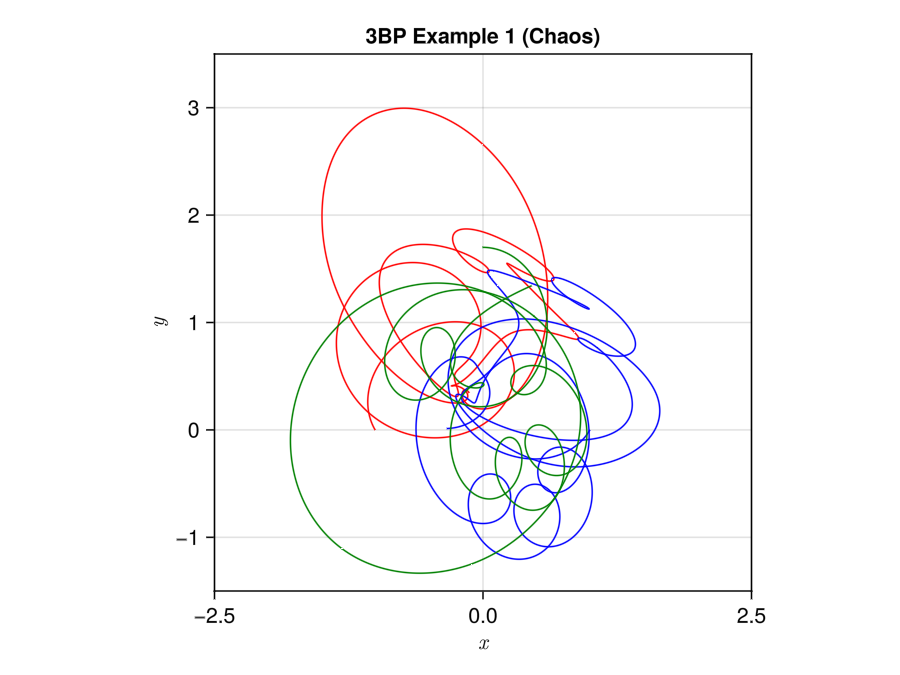

In [7]:
Makie.inline!(true)
fig = Figure()
ax = Axis(fig[1, 1]; title="3BP Example 1 (Chaos)", xlabel=L"x", ylabel=L"y", aspect = 1)
lines!(ax, sol[1, :], sol[2, :], linewidth=1, color=:red)
lines!(ax, sol[3, :], sol[4, :], linewidth=1, color=:blue)
lines!(ax, sol[5, :], sol[6, :], linewidth=1, color=:green)
xlims!(ax, -2.5, 2.5)
ylims!(ax, -1.5, 3.5)
fig

In [50]:
t_obs = Observable(0.0)
r1_obs = Observable(Point2f.(0.0, 0.0))
r2_obs = Observable(Point2f.(0.0, 0.0))
r3_obs = Observable(Point2f.(0.0, 0.0))
r1_his = Observable(zeros(2,size(sol)[2])*NaN)
r2_his = Observable(zeros(2,size(sol)[2])*NaN)
r3_his = Observable(zeros(2,size(sol)[2])*NaN)

println(typeof(r1_obs))
println(typeof(sol[1:2,1]))

Observable{Point{2, Float32}}
Vector{Float64}


In [51]:
fig2 = Figure()

ax2 = Axis(fig2[1, 1]; title = @lift(@sprintf("3BP Example 1 (Chaos)  t  = %0.2f\n", $t_obs)))
# ax2.title = @lift(@sprintf("3BP Example 1 (Chaos)  t  = %0.2f\n", $t_obs)
ax2.xlabel = L"x"
ax2.ylabel = L"y"
ax2.aspect = 1

scatter!(ax2, r1_obs, markersize=5, color=:red)
scatter!(ax2, r2_obs, markersize=5, color=:blue)
scatter!(ax2, r3_obs, markersize=5, color=:green)
lines!(ax2, r1_his, linewidth=1, color=:red)
lines!(ax2, r2_his, linewidth=1, color=:blue)
lines!(ax2, r3_his, linewidth=1, color=:green)
xlims!(ax2, -2.5, 2.5)
ylims!(ax2, -1.5, 3.5)

println(size(sol)[2])

record(fig2, "./output/3bp_chaos.gif") do io
    for itr in 1:50:size(sol)[2]
        t_obs[] = sol.t[itr]
        r1_obs[] = Point2f.(sol[1, itr], sol[2, itr])
        r2_obs[] = Point2f.(sol[3, itr], sol[4, itr])
        r3_obs[] = Point2f.(sol[5, itr], sol[6, itr])
        r1_his[] = sol[1:2, 1:itr]
        r2_his[] = sol[3:4, 1:itr]
        r3_his[] = sol[5:6, 1:itr]
        recordframe!(io)
    end
end

9960


"./output/3bp_chaos.gif"

## 円制限3体問題
ref: [Julia言語の常微分方程式ソルバーを使って円制限三体問題の軌道計算をしてみる 〜軌道伝播・境界値問題編〜](https://zenn.dev/naoyaozaki/articles/a3c0b199cdf23f)

In [11]:
# Equation of Motion of CRTBP
function eom_cr3bp!(dx,x,μ,t) #関数内で引数`dx`を変更するので，慣例にならって`!`を関数名の後ろに着けている
    # Preparation
    r1 = x[1:3] + [μ,0,0]
    r2 = x[1:3] - [1-μ,0,0]
    a_cori = [2x[5],-2x[4],0]
    a_cf = [x[1],x[2],0]
    # dx/dt
    dx[1:3] = x[4:6]
    dx[4:6] = -(1-μ)*r1/(norm(r1)^3) - μ*r2/(norm(r2)^3) + a_cori + a_cf
end

eom_cr3bp! (generic function with 1 method)

 14.363843 seconds (6.96 M allocations: 361.527 MiB, 2.70% gc time, 99.98% compilation time)


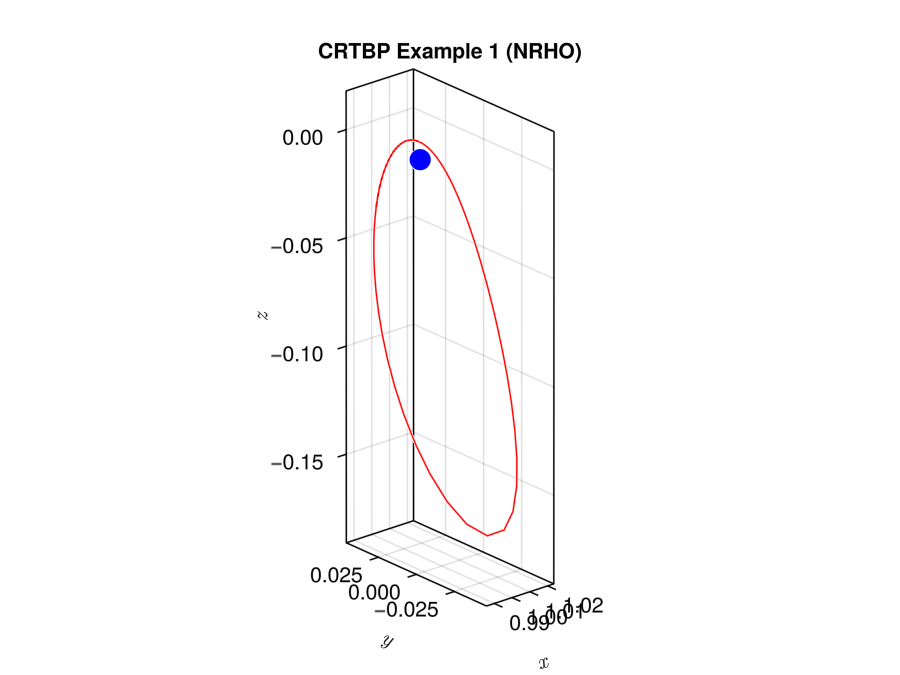

In [12]:
Makie.inline!(true)

# 問題定義 (地球・月系のNear-Rectilinear Halo Orbitを与える初期条件)
x0 = [0.987384153663276, 0.0, 0.008372273063008, 0.0, 1.67419265037912, 0.0]
tspan = (0.0, 0.5*pi)
μ = 0.01215058426994 # 地球・月系のμ
prob = ODEProblem(eom_cr3bp!, x0, tspan, μ)

# 計算
@time sol = solve(prob, DP8(), reltol=1e-10, abstol=1e-10)

# 描画
fig = Figure()
ax = Axis3(fig[1, 1]; aspect=:data, perspectiveness=0.0, title="CRTBP Example 1 (NRHO)", xlabel=L"x", ylabel=L"y", zlabel=L"z")
scatterlines!(ax, 1 - μ, 0, 0; markersize=20, color=:blue)
lines!(ax, sol[1, :], sol[2, :], sol[3, :], linewidth=1, color=:red)
fig

## 1.1) 基本概念の定義
### 1.1.1) 状態ベクトル
システムの自由度とは，そのシステムが各軸または各次元において持つ最小限の独立した運動能力を意味する。すなわち，システムの挙動を過剰に記述することなく記述するために必要な変数の個数である。
状態ベクトルは多次元ベクトル

\begin{align}
\boldsymbol{x}=\left[x_1, x_2, \ldots x_n\right]^{\top}
\end{align}

と定義され，各成分は任意の時刻におけるシステムの完全な構成を表す。状態ベクトルはシステムの現在の状態を数値的に表現するものであり，その値が分かれば，微分方程式を積分することによりシステムの時間発展を解析できる。

また，状態ベクトルの次元はシステムの自由度の少なくとも2倍である。たとえば，4輪駆動ロボット（メカナムホイール搭載）を考える。ここで，地面と平行なXY平面および上向きのZ軸を持つ三次元座標系を仮定すると，ロボットはZ軸周りの回転とX軸およびY軸方向の平行移動という3つの運動自由度を有する。ロボットの状態を完全に記述するには，XY平面上の位置 $(x,y)$ とZ軸周りの回転角 $\theta$ の情報が必要だが，さらに，これらの量の変化速度（すなわち，$\dot{x}$，$\dot{y}$，$\dot{\theta}$）も加える必要がある。これにより，状態ベクトルの次元は運動自由度の2倍以上となる。同様に，宇宙船の回転運動では，Euler角（$\phi$, $\theta$, $\psi$）と各軸周りの角速度（$\omega_x$, $\omega_y$, $\omega_z$）を用いる場合，状態ベクトルは6成分からなる。なお，クォータニオン表現を用いる場合は，クォータニオンの4成分と角速度3成分の計7成分となる。

### 1.1.2) 状態空間表現
状態ベクトルの概念を用いると，非線形動的システムは一般に以下の形で表される。

\begin{align}
\dot{\boldsymbol{x}}=\boldsymbol{f}(\boldsymbol{x}, t)
\end{align}

ここで，時刻 $t$ に明示的に依存する系は**非自律系**であり，時刻により応答が変化するため，たとえば軌道マニューバを伴う小惑星ランデブーなどでは，位置と時刻の両方が安定性の議論に影響を及ぼす。
一方，本講義では**自律系**，すなわち明示的な時刻依存性を持たないシステムを扱う。自律系の例として，室内で単純振り子の実験を行った場合，実験時刻に依存せず同一の結果が得られることが挙げられる。

実際，左辺が一階微分のみからなる場合，非自律系の一般形は一階常微分方程式となる。高階微分方程式も，たとえば

\begin{align}
\ddot{\theta}+a \sin (\theta)=0<br>
\text{where}  \quad a=Const.
\end{align}

のような式は，状態ベクトル 

\begin{align}
\boldsymbol{x}=\left[x_1, x_2\right]^{\top}=[\theta, \dot{\theta}]^{\top}
\end{align}

を導入することにより、以下の状態空間表現に変換できる。

\begin{align}
\dot{\boldsymbol{x}}=\left[x_2, a \sin x_1\right]^{\top}
\end{align}

このようにして，古典的な高階微分方程式は，状態空間表現として一階系に変換可能である。


### 1.2) 各テーマの概観

#### 1.2.1) 安定性
制御とは、自然が与えたシステムのダイナミクスを、望ましい形へと改変する手段である。たとえば、倒立状態の単純振り子は不安定であるが、適切なモーター駆動システムを用いて倒立振り子を垂直に維持することが可能である。ここでは、アクチュエータを用いて振り子の性質を変容させ、安定なシステムへと変化させる。なお「安定」とは何か、その本質を本講義において詳細に探求する。特に、非線形システムにおける安定性の概念が、線形ダイナミクスの場合といかに対照的であるかを明らかにする。

#### 1.2.2) 非線形制御
一部の研究者は「我々の制御は線形であり、あらゆる点で優れている」と主張する。しかし、実際のところ、現実世界のシステムは線形ではなく、宇宙船の運動学および運動力学の方程式は相互に複雑に結合しており、真に非線形である。確かに、方程式を線形化することで線形解析の手法を適用できるが、線形化は局所的な近似に過ぎず、制御の全体的な性能を保証するものではない。非線形ダイナミクスの安定性を厳密に保証するためには、非線形制御設計の解析的手法を用いる必要がある。本講義では、まさにこの非線形制御設計に焦点を当てる。

#### 1.2.3) 制御問題
本講義では、規制問題および追従問題に対する制御則を検討する。規制問題においては、まず所望の姿勢に対応する慣性座標系を定義し、その慣性座標系に対して全状態をゼロへと駆動することで、ボディ座標系を新たな慣性座標系に整合させる。たとえば、ハッブル宇宙望遠鏡が望遠鏡の向きをアンドロメダ銀河に向けるために姿勢補正を行う場合が挙げられる。ボディ座標系が仮想慣性座標系に整合すれば、姿勢制御のミッションは完了する。

一方、追従問題は、参照姿勢が時間とともに変動する中でその参照を追従する問題である。たとえば、地球を周回する観測衛星が、特定の地上地点を指向するためには、衛星の軌道運動に伴って参照となる姿勢も変動する。ある瞬間に誤差がゼロであっても、直後の参照姿勢を追従する必要がある。

#### 1.2.4) Lyapunov関数
線形ダイナミクス制御においては、古典的な微分方程式、状態空間表現、周波数領域の解析手法（ラプラス変換、根、ナイキスト安定判別、ルートローカス等）を用いて安定性を論じることができる。しかし、非線形ダイナミクスの場合、これらの手法は直接適用できない。そこで、Lyapunov関数という数学的手法が用いられる。Lyapunov関数は、システム状態と必ずしも線形に依存しないエネルギーに基づく関数であり、これを用いることで非線形制御則の設計およびその安定性の議論が可能となる。なお、Lyapunov関数の選定は重要かつ難解な課題であり、これが本講義におけるLyapunov理論の真髄とされる。講義では、Lyapunov理論の主要な要素を網羅し、Lyapunov関数に関する完全な講義を強く推奨する。

また、速度に基づく指標や姿勢状態に基づく指標をどのように設定するかは一筋縄では決まらない。姿勢問題では、対象がSO(3)群上にあるため、姿勢誤差は最大で180度に制限され、それを超えると逆に誤差が減少する。この特性がLyapunov関数にどのように反映されるかを、適切な候補関数を示しながら数学的に導出する。その後、座標系の選定、適切な指標の決定、そしてそれらを追従または規制問題に適用することで、具体的な制御則を構築する。

本講義では、まず基本的な定義を整理し、Lyapunov関数の概念を理解した上で、非線形フィードバック制御則の構築に必要な基礎要素を確立する。なお、姿勢推定の問題は取り扱わない。これは、推定自体が一講義に及ぶテーマであり、本講義では必要な状態フィードバックが既に与えられていることを前提とする。

